# Árvores de Decisão
### Análise, Limpeza e Codificação dos Dados

#### https://www.kaggle.com/code/sarayavari/decision-tree/notebook

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("heart.csv")

### FastingBS :
Glicemia em Jejum

### ResgingECG:
Eletrocardiograma em Repouso

### MAXHR:
Frequência Cardíaca Máxima

### ExerciseAngina: 
“Exercise Angina” ou “Exercise-Induced Angina” significa angina durante exercício. A Angina Pectoris é uma dor ou desconforto no peito que acontece quando o coração recebe menos oxigênio do que precisa. Ela pode surgir durante esforço físico, corrida, escadas ou exercícios.

### Oldpeak:
Ele representa a depressão do segmento ST no eletrocardiograma durante exercício em comparação ao repouso.
    
##### Em termos simples:
- mede uma alteração elétrica do coração durante esforço físico;
- ajuda a identificar possíveis sinais de redução do fluxo sanguíneo para o coração

### STSlope: significa a inclinação (slope) do segmento ST no eletrocardiograma após exercício físico.
O segmento ST é uma parte do traçado do ECG usada para avaliar como o coração responde ao esforço e se pode haver falta de oxigenação no músculo cardíaco.

Os valores mais comuns de STSlope são:

- Up (ascendente) → geralmente considerado mais normal
- Flat (reto/plano) → pode indicar alteração cardíaca
- Down (descendente) → costuma ser mais preocupante

In [9]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [7]:
df.shape

(918, 12)

In [5]:
df.isna().sum()



Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

<Axes: xlabel='Age', ylabel='Cholesterol'>

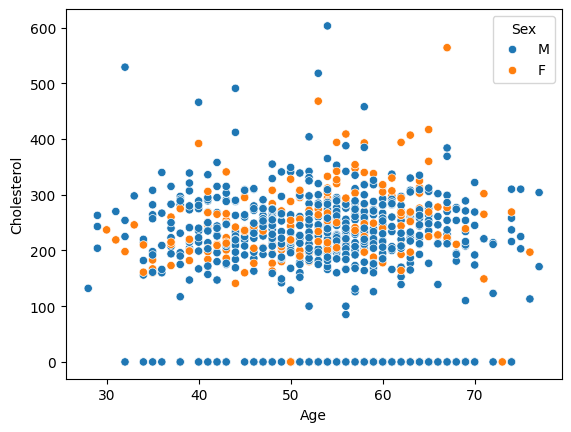

In [10]:
sns.scatterplot(data=df, x='Age',y='Cholesterol',hue='Sex')



<Axes: xlabel='Age', ylabel='Sex'>

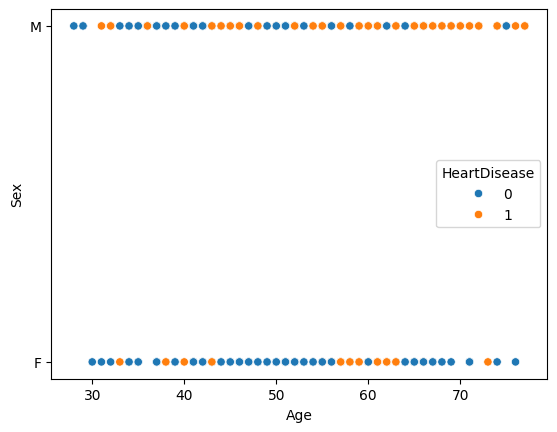

In [11]:
sns.scatterplot(data=df, x='Age',y='Sex',hue='HeartDisease')



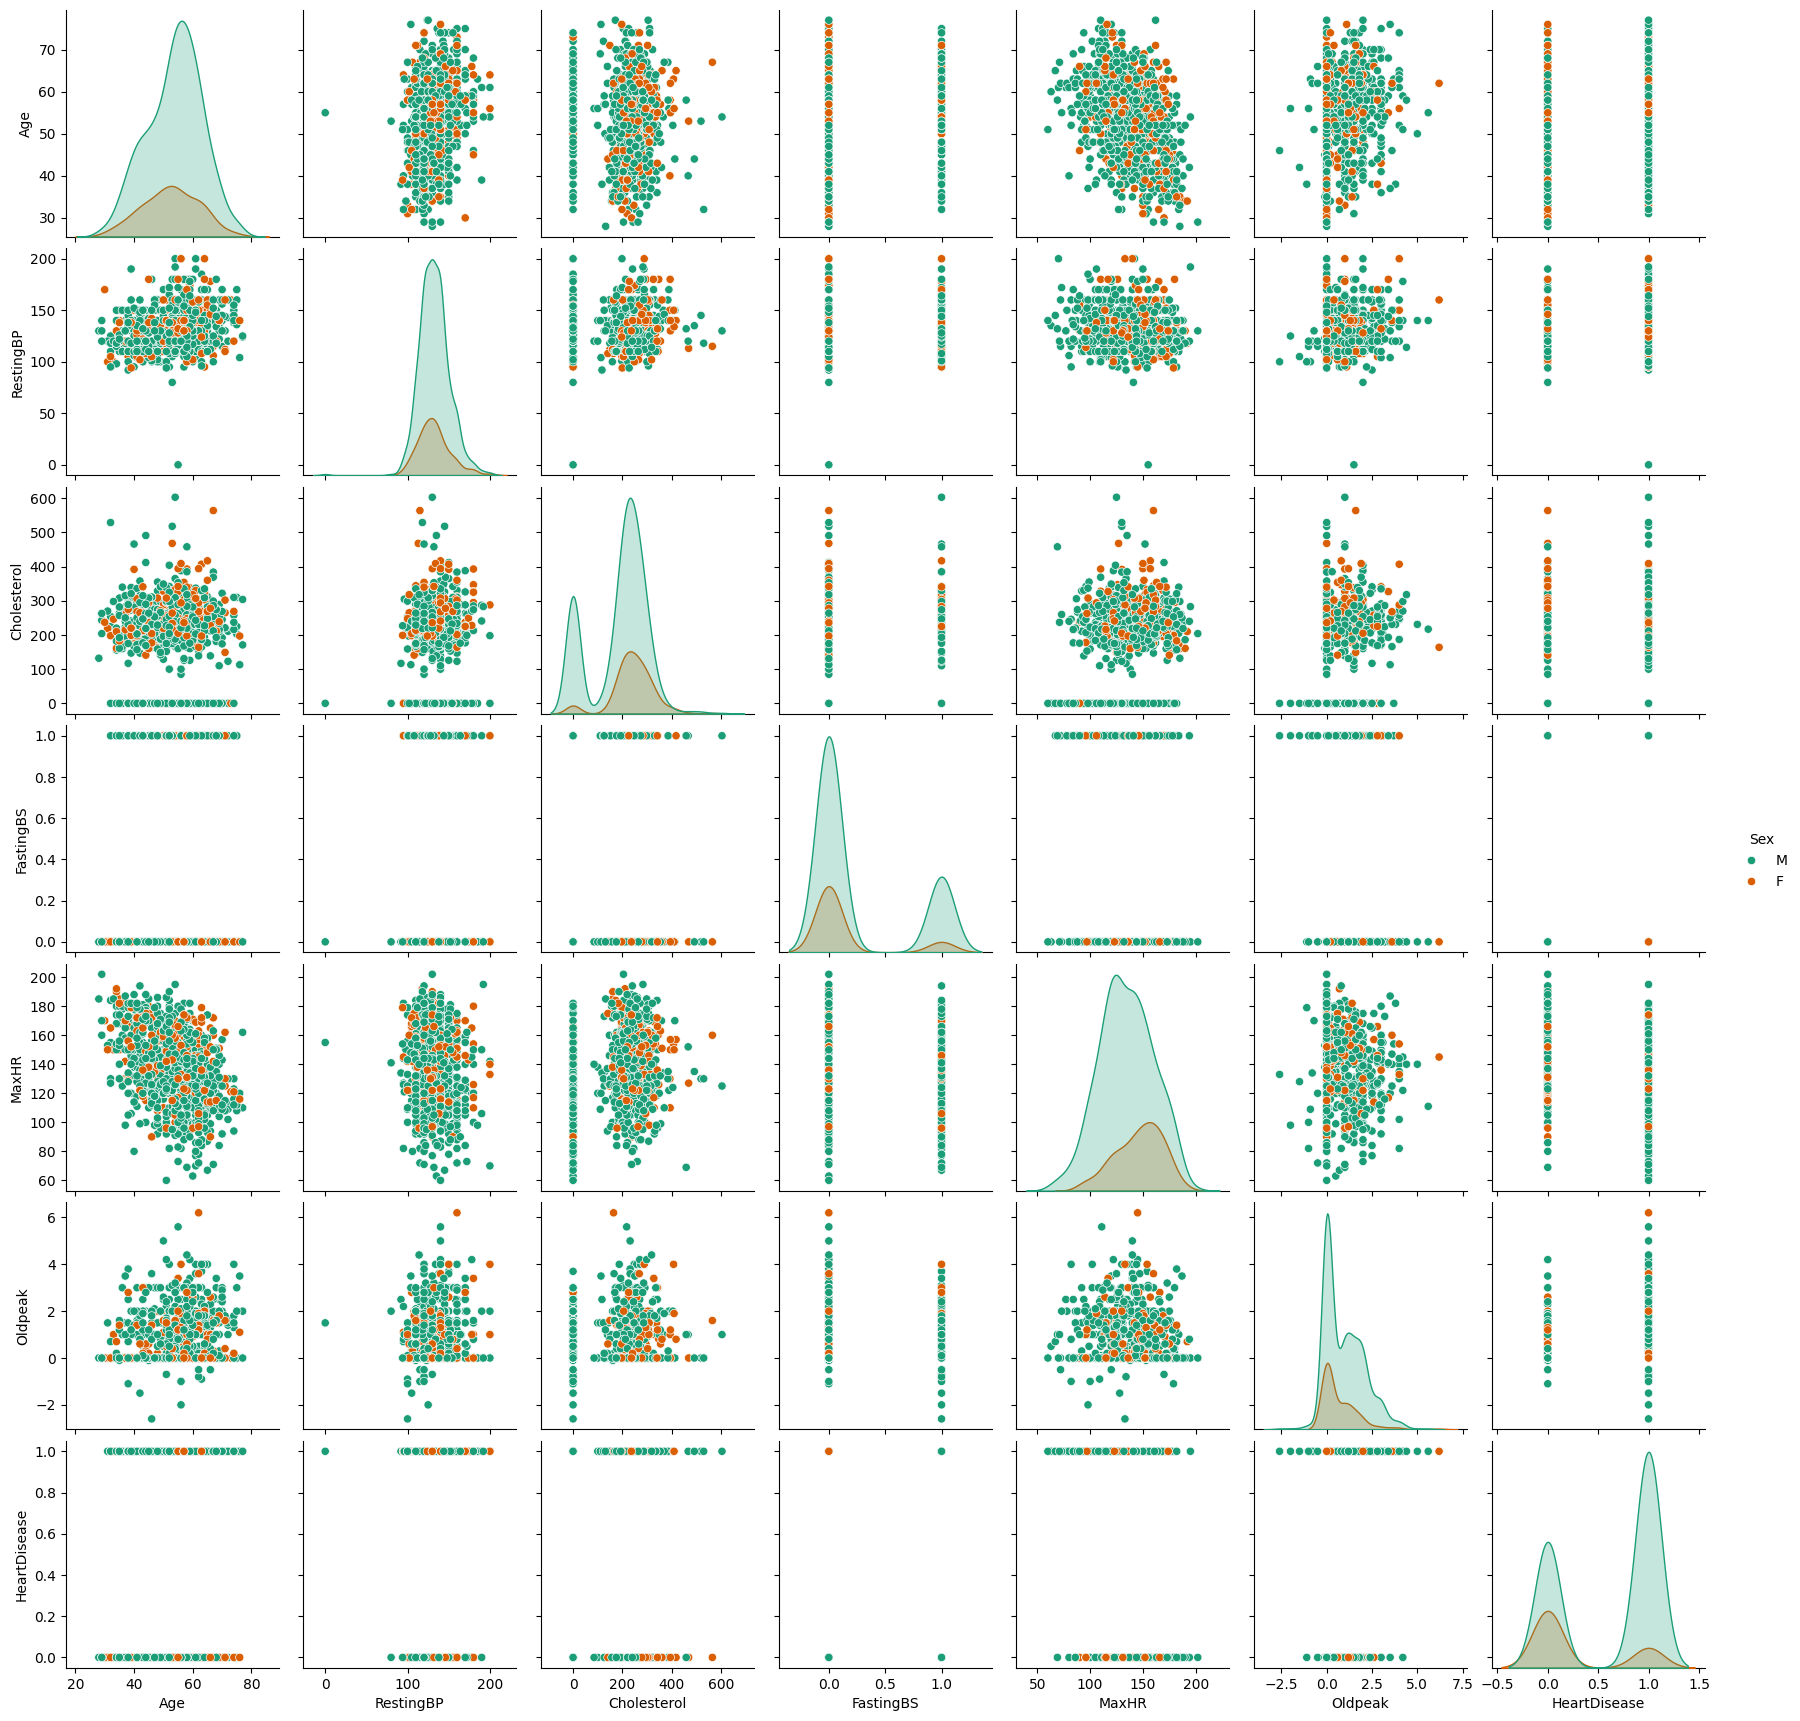

In [12]:
sns.pairplot(df,hue='Sex',palette='Dark2')



C:\Users\leona\AppData\Local\Temp\ipykernel_30604\3871518858.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(data=df, x='Sex',y='Age',kind='box',col='HeartDisease',palette='Dark2')


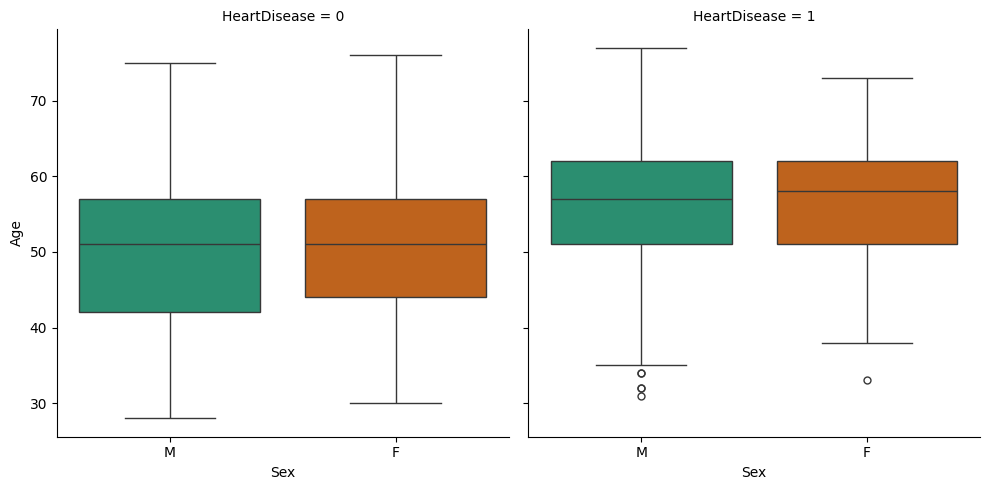

In [13]:
sns.catplot(data=df, x='Sex',y='Age',kind='box',col='HeartDisease',palette='Dark2')



<Axes: xlabel='Sex', ylabel='count'>

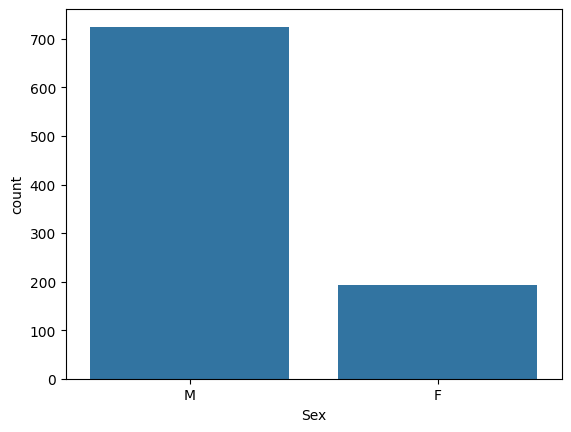

In [14]:
df['Sex'].value_counts()
sns.countplot(data=df, x='Sex')



<Axes: xlabel='Age', ylabel='count'>

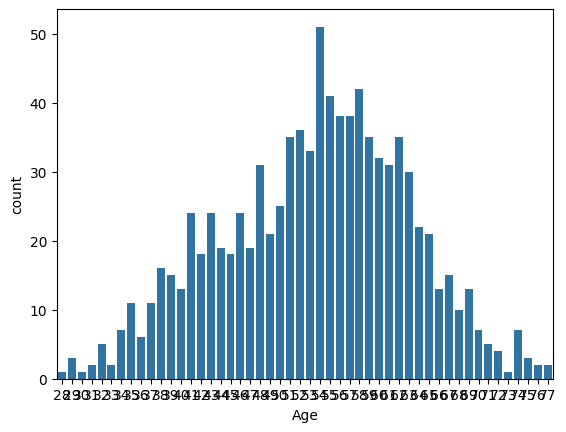

In [15]:
df["Age"].value_counts()
sns.countplot(data=df, x="Age")

In [16]:
# O método pd.get_dummies(df) da biblioteca pandas faz codificação de variáveis categóricas
# em formato numérico usando o esquema chamado one-hot encoding.
pd.get_dummies(df.drop('Sex',axis=1),drop_first=True)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,110,264,0,132,1.2,1,False,False,True,True,False,False,True,False
914,68,144,193,1,141,3.4,1,False,False,False,True,False,False,True,False
915,57,130,131,0,115,1.2,1,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,True,False,False,False,False,False,True,False


In [17]:
X = pd.get_dummies(df.drop('Sex',axis=1),drop_first=True)
y = df['Sex']



### Treinamento

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)



In [19]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)




In [20]:
from sklearn.metrics import confusion_matrix,classification_report

confusion_matrix(y_test, y_pred)

array([[ 26,  31],
       [ 57, 162]])

In [18]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           F       0.31      0.44      0.36        57
           M       0.84      0.75      0.79       219

    accuracy                           0.68       276
   macro avg       0.57      0.59      0.58       276
weighted avg       0.73      0.68      0.70       276



In [19]:
model.feature_importances_



array([0.16956015, 0.13381168, 0.26211785, 0.00511371, 0.16137504,
       0.06557012, 0.0888573 , 0.00861159, 0.01954087, 0.00297834,
       0.01184483, 0.00275093, 0.02287828, 0.02613975, 0.01884957])

In [21]:
pd.DataFrame(index=X.columns,data=model.feature_importances_,columns=['Feature Importance'])


,Feature Importance
Age,0.158822
RestingBP,0.140498
Cholesterol,0.242134
FastingBS,0.009778
MaxHR,0.173079
Oldpeak,0.086205
HeartDisease,0.088857
ChestPainType_ATA,0.008612
ChestPainType_NAP,0.025760
ChestPainType_TA,0.002978


[Text(0.5988880964730291, 0.9722222222222222, 'x[6] <= 0.5\ngini = 0.334\nsamples = 642\nvalue = [136, 506]'),
 Text(0.3767829356846473, 0.9166666666666666, 'x[2] <= 172.0\ngini = 0.454\nsamples = 284\nvalue = [99, 185]'),
 Text(0.48783551607883824, 0.9444444444444444, 'True  '),
 Text(0.30160788381742737, 0.8611111111111112, 'x[13] <= 0.5\ngini = 0.121\nsamples = 31\nvalue = [2, 29]'),
 Text(0.2933091286307054, 0.8055555555555556, 'gini = 0.0\nsamples = 26\nvalue = [0, 26]'),
 Text(0.3099066390041494, 0.8055555555555556, 'x[1] <= 116.0\ngini = 0.48\nsamples = 5\nvalue = [2, 3]'),
 Text(0.30160788381742737, 0.75, 'gini = 0.0\nsamples = 2\nvalue = [2, 0]'),
 Text(0.31820539419087135, 0.75, 'gini = 0.0\nsamples = 3\nvalue = [0, 3]'),
 Text(0.4519579875518672, 0.8611111111111112, 'x[0] <= 61.5\ngini = 0.473\nsamples = 253\nvalue = [97, 156]'),
 Text(0.39354253112033194, 0.8055555555555556, 'x[4] <= 176.5\ngini = 0.457\nsamples = 221\nvalue = [78, 143]'),
 Text(0.33480290456431533, 0.75, '

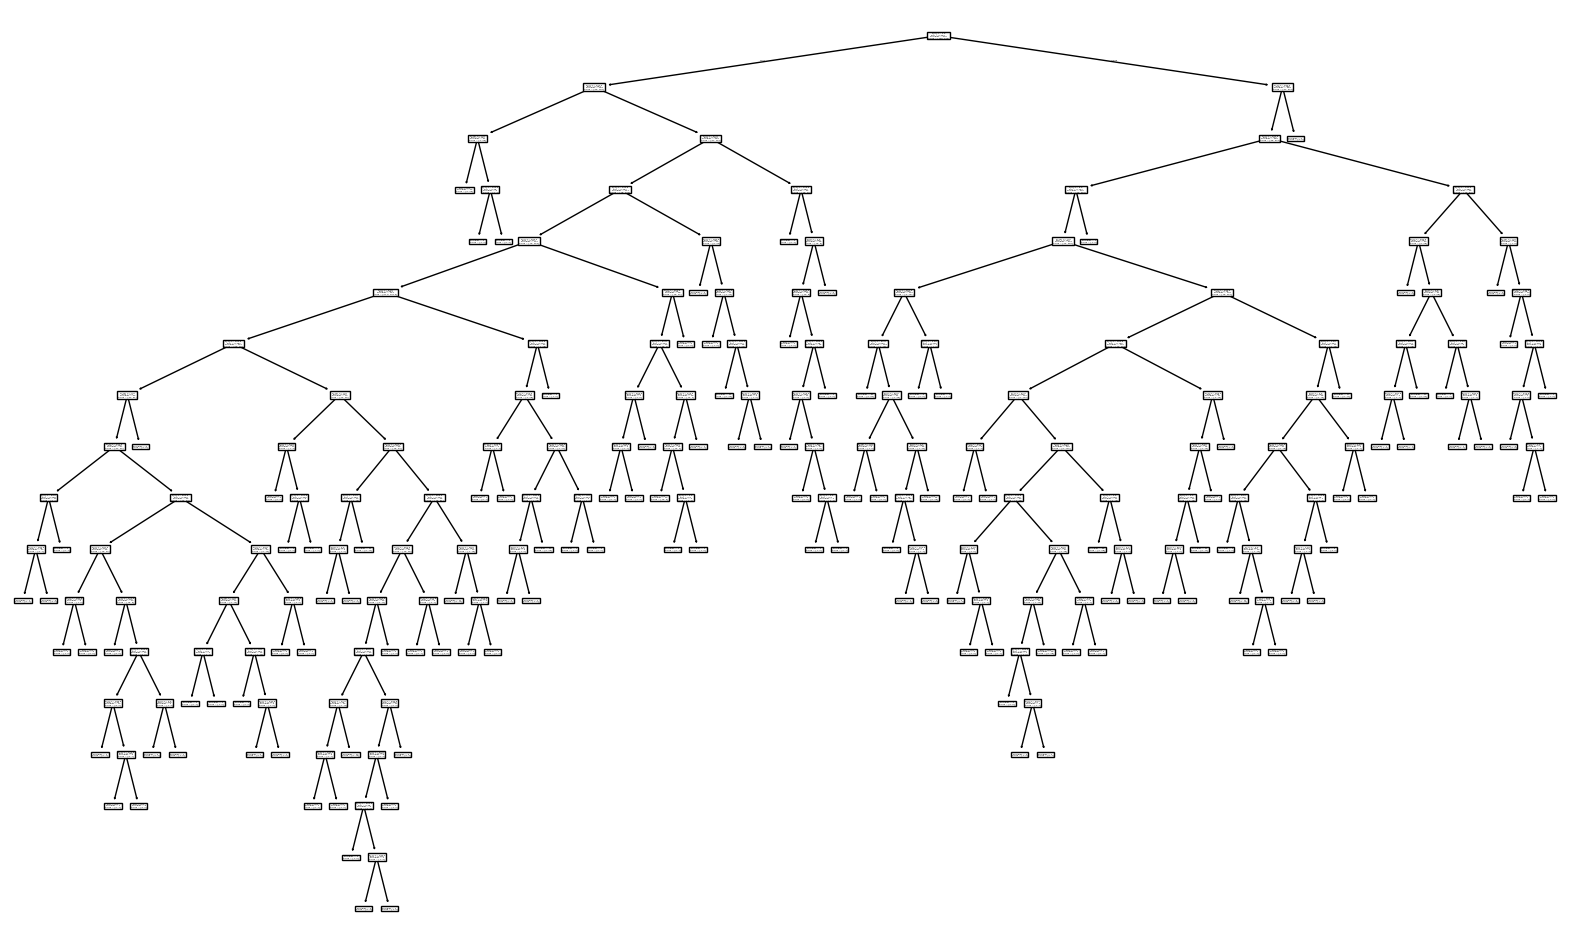

In [22]:
#Visualização e a Seleção por Entropia
from sklearn.tree import plot_tree
plt.figure(figsize=(20,12))
plot_tree(model)

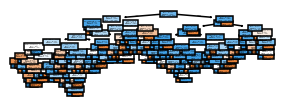

In [23]:
plt.figure(figsize=(3,1),dpi=110)
plot_tree(model,filled=True,feature_names=X.columns);



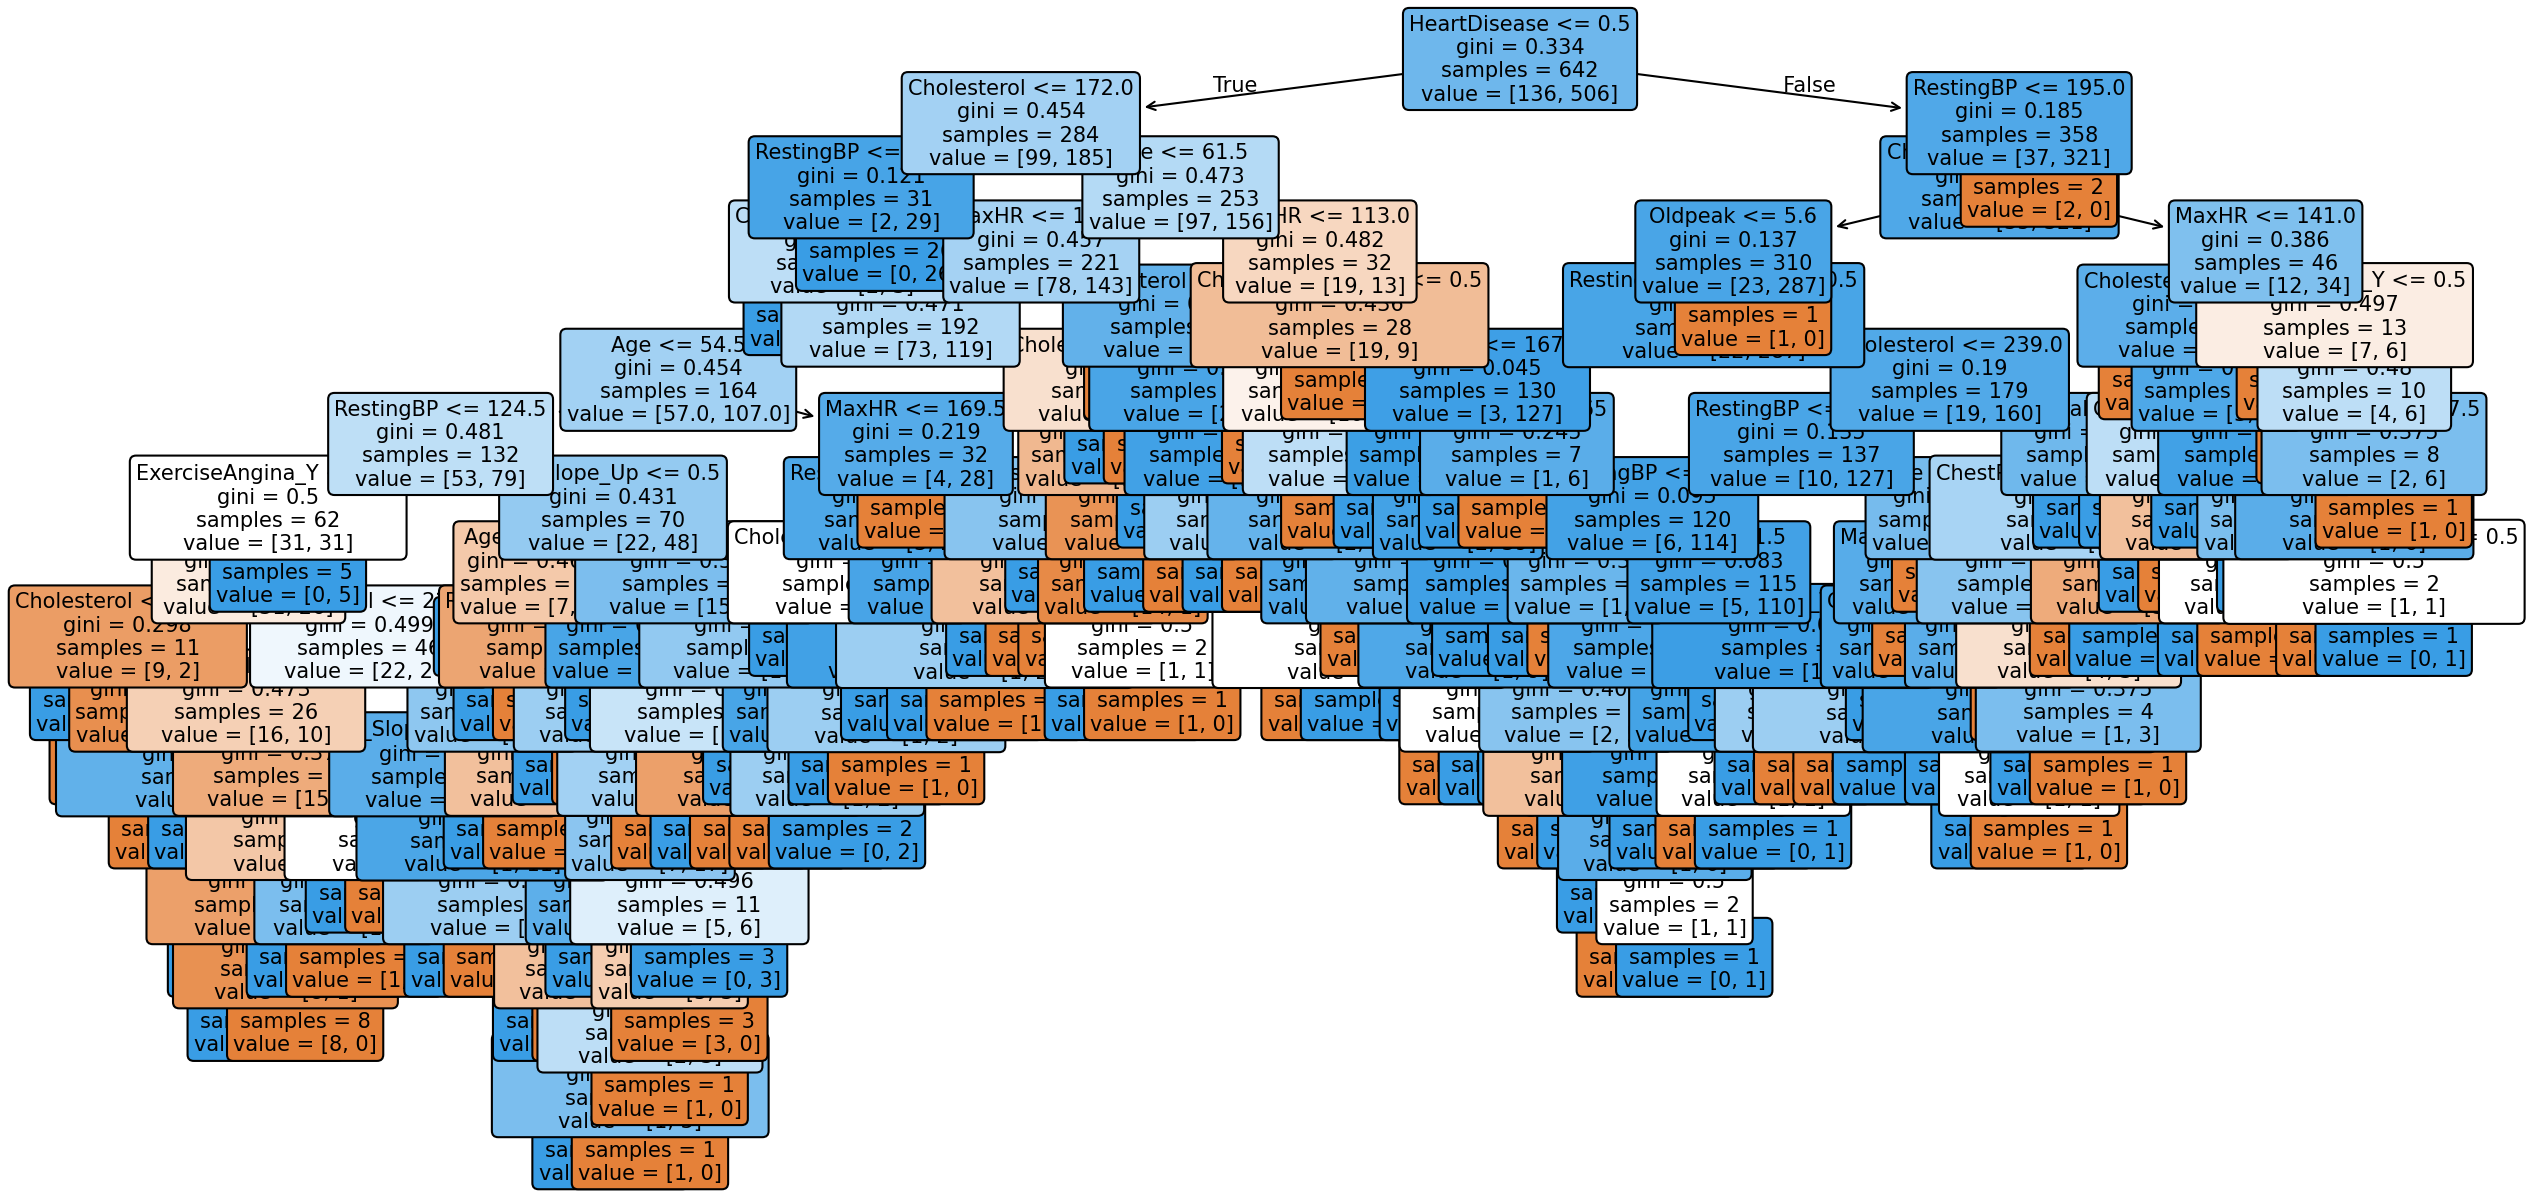

In [14]:
plt.figure(figsize=(20,10), dpi=150)
plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    fontsize=10,   # aumenta tamanho da fonte
    rounded=True   # deixa visual mais legível
)
plt.show()

In [1]:
# Exemplo do Tenis
import numpy as np
import pandas as pd
from sklearn import tree

df = pd.read_excel("jogartenis.xls")

print(df.head())

d = {'Sim': 1, 'Nao': 0}
df['JogarTenis'] = df['JogarTenis'].map(d)

d = {'Sol': 0, 'Nuvens': 1, 'Chuva': 2}
df['Aspecto'] = df['Aspecto'].map(d)

d = {'Quente': 0, 'Ameno': 1, 'Fresco': 2}
df['Temperatura'] = df['Temperatura'].map(d)

d = {'Normal': 0, 'Elevada': 1}
df['Humidade'] = df['Humidade'].map(d)

d = {'Fraco': 0, 'Forte': 1}
df['Vento'] = df['Vento'].map(d)

print(df.head())

X = df.drop("JogarTenis", axis=1)
y = df["JogarTenis"]

clf = tree.DecisionTreeClassifier()
clf.fit(X, y)

print("Score DecisionTreeClassifier:")
print(clf.score(X, y))

   Dia Aspecto Temperatura Humidade  Vento JogarTenis
0    1     Sol      Quente  Elevada  Fraco        Nao
1    2     Sol      Quente  Elevada  Forte        Nao
2    3  Nuvens      Quente  Elevada  Fraco        Sim
3    4   Chuva       Ameno  Elevada  Fraco        Sim
4    5   Chuva      Fresco   Normal  Fraco        Sim
   Dia  Aspecto  Temperatura  Humidade  Vento  JogarTenis
0    1        0            0         1      0           0
1    2        0            0         1      1           0
2    3        1            0         1      0           1
3    4        2            1         1      0           1
4    5        2            2         0      0           1
Score DecisionTreeClassifier:
1.0


In [3]:
import numpy as np
import pandas as pd
from sklearn import tree
from IPython.display import Image, display
from io import StringIO
import pydotplus

df = pd.read_excel("jogartenis.xls", sheet_name=0)

print(df.head())

d = {'Sim': 1, 'Nao': 0}
df['JogarTenis'] = df['JogarTenis'].map(d)

d = {'Sol': 0, 'Nuvens': 1, 'Chuva': 2}
df['Aspecto'] = df['Aspecto'].map(d)

d = {'Quente': 0, 'Ameno': 1, 'Fresco': 2}
df['Temperatura'] = df['Temperatura'].map(d)

d = {'Normal': 0, 'Elevada': 1}
df['Humidade'] = df['Humidade'].map(d)

d = {'Fraco': 0, 'Forte': 1}
df['Vento'] = df['Vento'].map(d)

print(df.head())

X = df.drop("JogarTenis", axis=1)
y = df["JogarTenis"]

clf = tree.DecisionTreeClassifier()
clf.fit(X, y)

print(clf.score(X, y))

dot_data = StringIO()

tree.export_graphviz(
    clf,
    out_file=dot_data,
    feature_names=X.columns
)

graph = pydotplus.graphviz.graph_from_dot_data(dot_data.getvalue())

display(Image(graph.create_png()))


   Dia Aspecto Temperatura Humidade  Vento JogarTenis
0    1     Sol      Quente  Elevada  Fraco        Nao
1    2     Sol      Quente  Elevada  Forte        Nao
2    3  Nuvens      Quente  Elevada  Fraco        Sim
3    4   Chuva       Ameno  Elevada  Fraco        Sim
4    5   Chuva      Fresco   Normal  Fraco        Sim
   Dia  Aspecto  Temperatura  Humidade  Vento  JogarTenis
0    1        0            0         1      0           0
1    2        0            0         1      1           0
2    3        1            0         1      0           1
3    4        2            1         1      0           1
4    5        2            2         0      0           1
1.0


InvocationException: GraphViz's executables not found